In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [4]:
housing_df = fetch_california_housing(as_frame=True)
housing_df = housing_df.frame
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


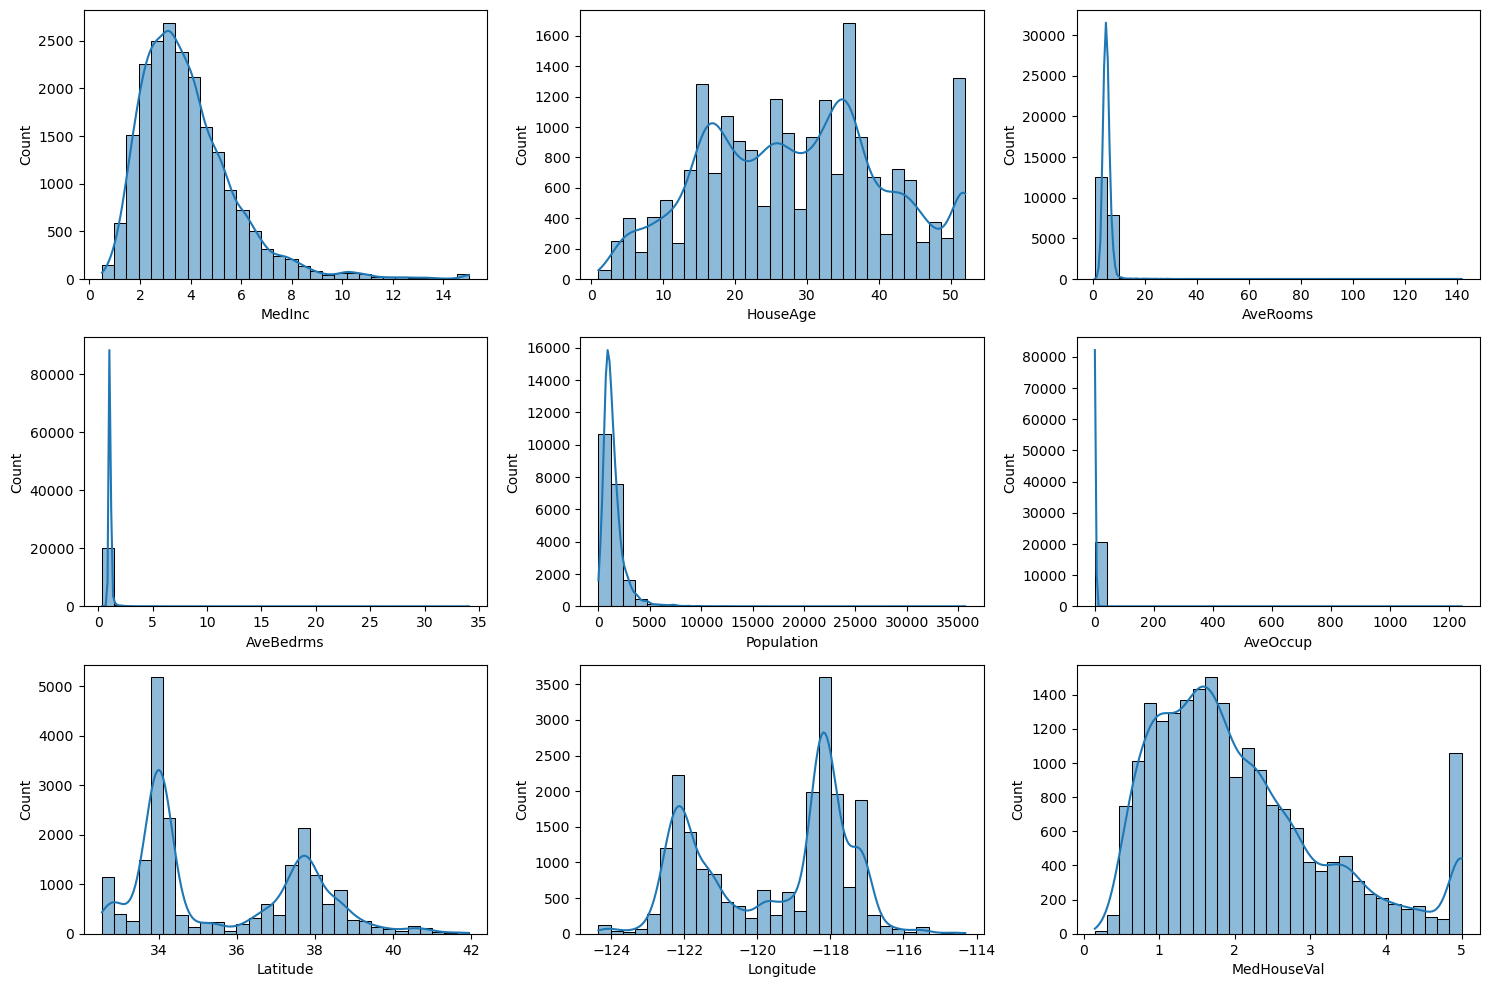

In [5]:
# histogram

num_cols = housing_df.select_dtypes(include='number')

plt.figure(figsize=(15,10))
for i,col in enumerate(num_cols.columns):
    
    plt.subplot(3,3,i+1)
    sns.histplot(num_cols[col],kde=True,bins=30)
    
plt.tight_layout()
plt.show()

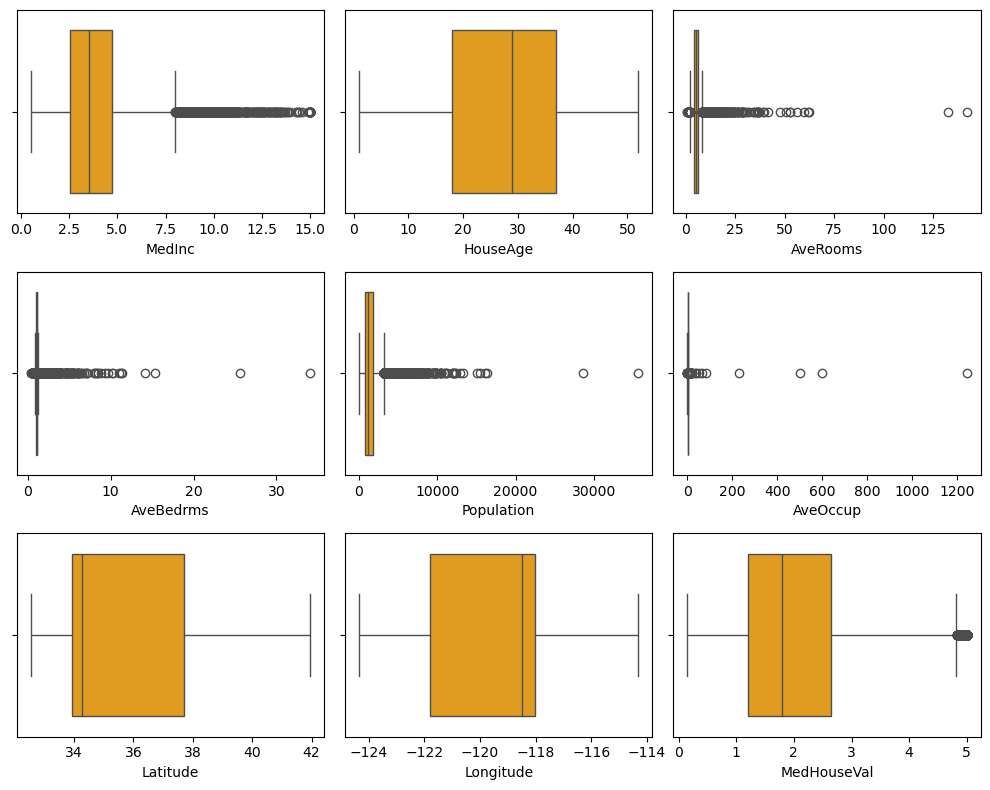

In [9]:
# boxplot

plt.figure(figsize=(10,8))
for i,col in enumerate(num_cols.columns):
    
    plt.subplot(3,3,i+1)
    sns.boxplot(x=num_cols[col],color='orange')
    
plt.tight_layout()
plt.show()

In [21]:
# outlier

outlier_summary = {}


for col in num_cols.columns:
    
    Q1 = num_cols[col].quantile(0.25)
    Q3 = num_cols[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = num_cols[(num_cols[col] < Q1 - 1.5*IQR) | (num_cols[col] > Q3 + 1.5*IQR) ]
    
    outlier_summary[col] = len(outliers)
    print(f"{col}: {len(outliers)} outliers")
    
    
print("-------------------")
for key,value in outlier_summary.items():
    print(f"{key}:  {value} outliers")

MedInc: 681 outliers
HouseAge: 0 outliers
AveRooms: 511 outliers
AveBedrms: 1424 outliers
Population: 1196 outliers
AveOccup: 711 outliers
Latitude: 0 outliers
Longitude: 0 outliers
MedHouseVal: 1071 outliers
-------------------
MedInc:  681 outliers
HouseAge:  0 outliers
AveRooms:  511 outliers
AveBedrms:  1424 outliers
Population:  1196 outliers
AveOccup:  711 outliers
Latitude:  0 outliers
Longitude:  0 outliers
MedHouseVal:  1071 outliers


In [22]:
outlier_summary.items()

dict_items([('MedInc', 681), ('HouseAge', 0), ('AveRooms', 511), ('AveBedrms', 1424), ('Population', 1196), ('AveOccup', 711), ('Latitude', 0), ('Longitude', 0), ('MedHouseVal', 1071)])